In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm
from collections import Counter

Setup Device + Chemins

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs("../models",  exist_ok=True)
os.makedirs("../results", exist_ok=True)

OCT_PATH    = "../data/OCT_aug"
MODEL_PATH   = "../models/efficientnet_OCT_best.pth"
HISTORY_P1   = "../results/history_efficientnet_OCT_p1.json"
HISTORY_P2   = "../results/history_efficientnet_OCT_p2.json"

Device : cuda


DataLoaders


In [12]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

OCT_train_loader = DataLoader(
    datasets.ImageFolder(f"{OCT_PATH}/train", transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)
OCT_val_loader = DataLoader(
    datasets.ImageFolder(f"{OCT_PATH}/val", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)
OCT_test_loader = DataLoader(
    datasets.ImageFolder(f"{OCT_PATH}/test", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)

print("✅ DataLoaders OCT chargés !")
print(f"   Train  : {len(OCT_train_loader.dataset)} images")
print(f"   Val    : {len(OCT_val_loader.dataset)} images")
print(f"   Test   : {len(OCT_test_loader.dataset)} images")
print(f"   Classes: {OCT_train_loader.dataset.class_to_idx}")

✅ DataLoaders OCT chargés !
   Train  : 128393 images
   Val    : 9229 images
   Test   : 15373 images
   Classes: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}


Construire EfficientNetB0

In [8]:
def build_efficientnet(num_classes, device):
    """
    Transfer Learning EfficientNetB0 :
    1. Charger poids pré-entraînés ImageNet
    2. Geler toutes les couches
    3. Remplacer le classifier final
    """

    # ── Charger EfficientNetB0 pré-entraîné ───────────────
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

    # ── Geler toutes les couches ───────────────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Remplacer le classifier final ─────────────────────
    # EfficientNetB0 → in_features = 1280 (différent de ResNet)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )

    model = model.to(device)

    # ── Résumé ─────────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                          if p.requires_grad)

    print(f"✅ EfficientNetB0 chargé !")
    print(f"   Total params     : {total_params:,}")
    print(f"   Trainable params : {trainable_params:,}")
    print(f"   Frozen params    : {total_params-trainable_params:,}")
    print(f"   in_features      : {in_features}")
    print(f"   num_classes      : {num_classes}")

    return model

# OCT → 5 classes
efficientnet_oct = build_efficientnet(num_classes=5, device=device)

✅ EfficientNetB0 chargé !
   Total params     : 4,665,985
   Trainable params : 658,437
   Frozen params    : 4,007,548
   in_features      : 1280
   num_classes      : 5


Loss, Optimizer, Scheduler

In [9]:
# ── Loss ──────────────────────────────────────────────────
# OCT = 5 classes → CrossEntropyLoss
criterion_oct = nn.CrossEntropyLoss()

# ── Optimizer Phase 1 ─────────────────────────────────────
optimizer_oct = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_oct.parameters()),
    lr=1e-3
)

# ── Scheduler ─────────────────────────────────────────────
scheduler_oct = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_oct,
    mode    ='min',
    factor  = 0.5,
    patience= 3
)

print("✅ Loss     : CrossEntropyLoss")
print("✅ Optimizer: Adam (lr=1e-3)")
print("✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

✅ Loss     : CrossEntropyLoss
✅ Optimizer: Adam (lr=1e-3)
✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


Fonctions Train et Eval

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

Fonction Entraînement avec sauvegarde JSON

In [11]:
def entrainer_modele(model, train_loader, val_loader,
                     criterion, optimizer, scheduler,
                     num_epochs, device,
                     save_path, history_path):

    historique = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    meilleure_val_loss  = float('inf')
    patience_counter    = 0
    EARLY_STOP_PATIENCE = 7

    print(f"{'='*60}")
    print(f"  Début entraînement — {num_epochs} epochs max")
    print(f"  Modèle sauvegardé  : {save_path}")
    print(f"  Historique JSON    : {history_path}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):

        # ── Train ──────────────────────────────────────────
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # ── Validation ─────────────────────────────────────
        val_loss, val_acc = eval_epoch(
            model, val_loader, criterion, device
        )

        # ── Scheduler ──────────────────────────────────────
        scheduler.step(val_loss)

        # ── Sauvegarder historique ──────────────────────────
        historique['train_loss'].append(train_loss)
        historique['train_acc'].append(train_acc)
        historique['val_loss'].append(val_loss)
        historique['val_acc'].append(val_acc)

        # ── Sauvegarde JSON après chaque epoch ─────────────
        with open(history_path, 'w') as f:
            json.dump(historique, f, indent=2)

        # ── Affichage ───────────────────────────────────────
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} "
              f"Val Acc: {val_acc:.4f}")

        # ── Sauvegarder meilleur modèle ─────────────────────
        if val_loss < meilleure_val_loss:
            meilleure_val_loss = val_loss
            patience_counter   = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Meilleur modèle sauvegardé ! "
                  f"(val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  ⚠️  Pas d'amélioration "
                  f"({patience_counter}/{EARLY_STOP_PATIENCE})")

        # ── Early Stopping ──────────────────────────────────
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n🛑 Early stopping epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"  Entraînement terminé !")
    print(f"  Meilleure val_loss : {meilleure_val_loss:.4f}")
    print(f"{'='*60}")

    return historique

Phase 1 : Feature Extraction

In [14]:
print("PHASE 1 — Feature Extraction")
print("Toutes les couches EfficientNet gelées")
print("Seul le classifier est entraîné\n")

historique_p1 = entrainer_modele(
    model        = efficientnet_oct,
    train_loader = OCT_train_loader,
    val_loader   = OCT_val_loader,
    criterion    = criterion_oct,
    optimizer    = optimizer_oct,
    scheduler    = scheduler_oct,
    num_epochs   = 10,
    device       = device,
    save_path    = "../models/efficientnet_oct_phase1.pth",
    history_path = HISTORY_P1
)

PHASE 1 — Feature Extraction
Toutes les couches EfficientNet gelées
Seul le classifier est entraîné

  Début entraînement — 10 epochs max
  Modèle sauvegardé  : ../models/efficientnet_oct_phase1.pth
  Historique JSON    : ../results/history_efficientnet_OCT_p1.json



Epoch [  1/10] Train Loss: 0.6326 Train Acc: 0.7381 | Val Loss: 0.4713 Val Acc: 0.8226
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.4713)


Epoch [  2/10] Train Loss: 0.5845 Train Acc: 0.7587 | Val Loss: 0.4435 Val Acc: 0.8330
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.4435)


Epoch [  3/10] Train Loss: 0.5710 Train Acc: 0.7651 | Val Loss: 0.4511 Val Acc: 0.8315
  ⚠️  Pas d'amélioration (1/7)


Epoch [  4/10] Train Loss: 0.5608 Train Acc: 0.7711 | Val Loss: 0.4573 Val Acc: 0.8298
  ⚠️  Pas d'amélioration (2/7)


...

Epoch [  6/10] Train Loss: 0.5510 Train Acc: 0.7754 | Val Loss: 0.4244 Val Acc: 0.8426
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.4244)


Epoch [  7/10] Train Loss: 0.5437 Train Acc: 0.7779 | Val Loss: 0.4281 Val Acc: 0.8428
  ⚠️  Pas d'amélioration (1/7)


Epoch [  8/10] Train Loss: 0.5401 Train Acc: 0.7802 | Val Loss: 0.4301 Val Acc: 0.8400
  ⚠️  Pas d'amélioration (2/7)


Epoch [  9/10] Train Loss: 0.5357 Train Acc: 0.7810 | Val Loss: 0.4173 Val Acc: 0.8473
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.4173)


Epoch [ 10/10] Train Loss: 0.5319 Train Acc: 0.7838 | Val Loss: 0.4025 Val Acc: 0.8526
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.4025)

  Entraînement terminé !
  Meilleure val_loss : 0.4025


Phase 2 : Fine-Tuning

In [16]:
print("PHASE 2 — Fine-Tuning")
print("Dégel des dernières couches EfficientNet\n")

# ── Dégeler les dernières couches ─────────────────────────
for param in efficientnet_oct.features[-3:].parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in efficientnet_oct.parameters()
                if p.requires_grad)
print(f"Params entraînables après dégel : {trainable:,}\n")

# ── Nouvel optimizer lr plus petit ────────────────────────
optimizer_oct_ft = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_oct.parameters()),
    lr=1e-5
)

scheduler_oct_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_oct_ft,
    mode='min', factor=0.5, patience=3
)

historique_p2 = entrainer_modele(
    model        = efficientnet_oct,
    train_loader = OCT_train_loader,
    val_loader   = OCT_val_loader,
    criterion    = criterion_oct,
    optimizer    = optimizer_oct_ft,
    scheduler    = scheduler_oct_ft,
    num_epochs   = 5,
    device       = device,
    save_path    = MODEL_PATH,
    history_path = HISTORY_P2
)

PHASE 2 — Fine-Tuning
Dégel des dernières couches EfficientNet

Params entraînables après dégel : 3,814,177

  Début entraînement — 5 epochs max
  Modèle sauvegardé  : ../models/efficientnet_OCT_best.pth
  Historique JSON    : ../results/history_efficientnet_OCT_p2.json



Epoch [  1/5] Train Loss: 0.4008 Train Acc: 0.8418 | Val Loss: 0.2695 Val Acc: 0.9058
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.2695)


Epoch [  2/5] Train Loss: 0.3149 Train Acc: 0.8786 | Val Loss: 0.2345 Val Acc: 0.9180
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.2345)


Epoch [  3/5] Train Loss: 0.2734 Train Acc: 0.8946 | Val Loss: 0.2214 Val Acc: 0.9259
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.2214)


Epoch [  4/5] Train Loss: 0.2421 Train Acc: 0.9066 | Val Loss: 0.2090 Val Acc: 0.9301
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.2090)


Epoch [  5/5] Train Loss: 0.2216 Train Acc: 0.9155 | Val Loss: 0.1924 Val Acc: 0.9340
  ✅ Meilleur modèle sauvegardé ! (val_loss=0.1924)

  Entraînement terminé !
  Meilleure val_loss : 0.1924


Visualiser courbes depuis JSON

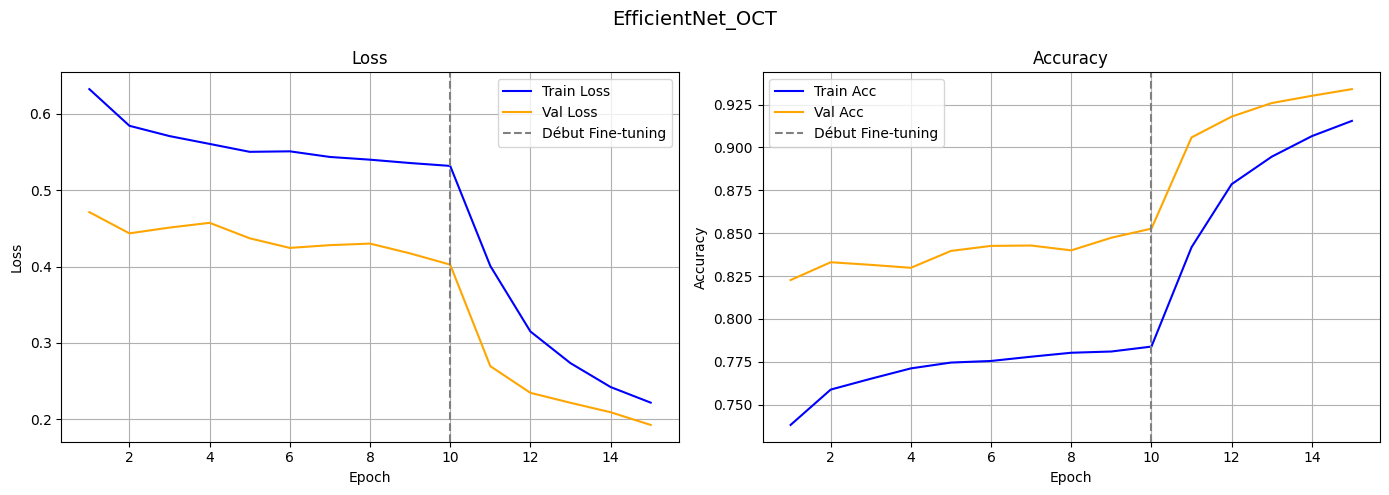


  Résumé — EfficientNet_OCT
  Phase 1        : 10 epochs
  Phase 2        : 5 epochs
  Meilleure Val Loss : 0.1924
  Meilleure Val Acc  : 93.40%


In [17]:
def plot_depuis_json(path_p1, path_p2, titre):

    with open(path_p1, 'r') as f:
        hist1 = json.load(f)
    with open(path_p2, 'r') as f:
        hist2 = json.load(f)

    train_loss = hist1['train_loss'] + hist2['train_loss']
    val_loss   = hist1['val_loss']   + hist2['val_loss']
    train_acc  = hist1['train_acc']  + hist2['train_acc']
    val_acc    = hist1['val_acc']    + hist2['val_acc']
    epochs     = range(1, len(train_loss) + 1)
    sep        = len(hist1['train_loss'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titre, fontsize=14)

    # ── Loss ───────────────────────────────────────────────
    axes[0].plot(epochs, train_loss, label='Train Loss', color='blue')
    axes[0].plot(epochs, val_loss,   label='Val Loss',   color='orange')
    axes[0].axvline(x=sep, color='gray',
                    linestyle='--', label='Début Fine-tuning')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ── Accuracy ───────────────────────────────────────────
    axes[1].plot(epochs, train_acc, label='Train Acc', color='blue')
    axes[1].plot(epochs, val_acc,   label='Val Acc',   color='orange')
    axes[1].axvline(x=sep, color='gray',
                    linestyle='--', label='Début Fine-tuning')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"../results/{titre}.png")
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Résumé — {titre}")
    print(f"{'='*45}")
    print(f"  Phase 1        : {len(hist1['train_loss'])} epochs")
    print(f"  Phase 2        : {len(hist2['train_loss'])} epochs")
    print(f"  Meilleure Val Loss : {min(val_loss):.4f}")
    print(f"  Meilleure Val Acc  : {max(val_acc)*100:.2f}%")

plot_depuis_json(HISTORY_P1, HISTORY_P2, "EfficientNet_OCT")

Évaluation sur Test Set

In [27]:
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import seaborn as sns

efficientnet_oct.eval()

# ── Prédictions sur tout le test set ──────────────────────
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(OCT_test_loader, desc="Test"):
        images  = images.to(device)
        outputs = efficientnet_oct(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
classes    = list(OCT_test_loader.dataset.class_to_idx.keys())

# ── Vérification ───────────────────────────────────────────
print(f"all_labels shape : {all_labels.shape}")
print(f"all_probs shape  : {all_probs.shape}")
# ✅ attendu → (15373, 4)

# ── Métriques ──────────────────────────────────────────────
print("\n" + "=" * 55)
print("  ÉVALUATION — EfficientNet OCT")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                             target_names=classes))



Test: 100%|██████████| 481/481 [04:14<00:00,  1.89it/s]

all_labels shape : (15373,)
all_probs shape  : (15373, 5)

  ÉVALUATION — EfficientNet OCT
              precision    recall  f1-score   support

         CNV       0.95      0.96      0.96      6330
         DME       0.95      0.89      0.92      2219
      DRUSEN       0.87      0.73      0.79      1568
      NORMAL       0.93      0.99      0.96      5256

    accuracy                           0.94     15373
   macro avg       0.92      0.89      0.91     15373
weighted avg       0.94      0.94      0.94     15373



AUC-ROC : 0.9890


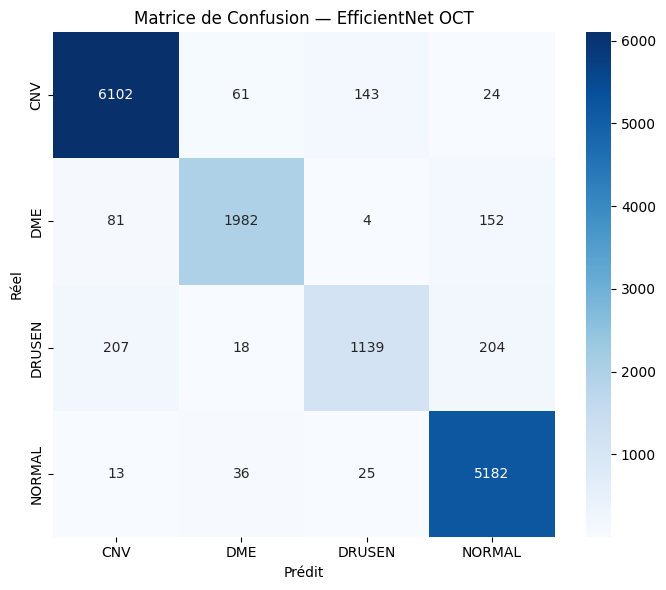


✅ Métriques sauvegardées !


In [28]:
# ── AUC-ROC multiclasse ────────────────────────────────────
auc = roc_auc_score(
    all_labels,
    all_probs[:, :len(classes)],
    multi_class='ovr',
    average='macro'
)
print(f"AUC-ROC : {auc:.4f}")

# ── Matrice de confusion ───────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title("Matrice de Confusion — EfficientNet OCT")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/confusion_efficientnet_oct.png")
plt.show()

# ── Sauvegarder métriques JSON ─────────────────────────────
metriques = {
    "model"   : "EfficientNetB0",
    "dataset" : "OCT",
    "accuracy": float((all_preds == all_labels).mean()),
    "auc_roc" : float(auc),
    "classes" : classes
}

with open("../results/metriques_efficientnet_oct.json", "w") as f:
    json.dump(metriques, f, indent=2)

print("\n✅ Métriques sauvegardées !")